In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#getting data ready
heart_disease = pd.read_csv("./datasets/dataset.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [6]:
#choose right estimator
x_axis = heart_disease.drop("target", axis = 1)
y_axis = heart_disease["target"]

In [7]:
#choose correct algorithm
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
#n_estimators is number of descesion trees that is taken into consideration

In [8]:
#keep default hyperparameter
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [9]:
#fit the model to the taraining data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_axis ,y_axis, test_size=0.2)

In [10]:
clf.fit(x_train, y_train)

RandomForestClassifier()

In [11]:
y_preds = clf.predict(x_test)
y_preds

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [12]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
127,67,0,2,152,277,0,1,172,0,0.0,2,1,2
43,53,0,0,130,264,0,0,143,0,0.4,1,0,2
257,50,1,0,144,200,0,0,126,1,0.9,1,0,3
280,42,1,0,136,315,0,1,125,1,1.8,1,0,1
187,54,1,0,124,266,0,0,109,1,2.2,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,59,1,3,178,270,0,0,145,0,4.2,0,0,3
282,59,1,2,126,218,1,1,134,0,2.2,1,1,1
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
131,49,0,1,134,271,0,1,162,0,0.0,1,0,2


In [13]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
90,48,1,2,124,255,1,1,175,0,0.0,2,2,2
11,48,0,2,130,275,0,1,139,0,0.2,2,0,2
283,40,1,0,152,223,0,1,181,0,0.0,2,0,3
135,49,0,0,130,269,0,1,163,0,0.0,2,0,2
84,42,0,0,102,265,0,0,122,0,0.6,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,42,1,0,140,226,0,1,178,0,0.0,2,0,2
291,58,1,0,114,318,0,2,140,0,4.4,0,3,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2
74,43,0,2,122,213,0,1,165,0,0.2,1,0,2


In [ ]:
#evaluate the model
clf.score(x_train, y_train) 

1.0

#cross_val_score is another method for evaluating ml model, it uses `cross validation` to train

In [15]:
from  sklearn.model_selection import cross_val_score

cv_acc = cross_val_score(clf, x_axis ,y_axis, cv = 5, scoring = "accuracy")
print(cv_acc)

print(f'The cross validation average is : {cv_acc.mean()}')

[0.83606557 0.8852459  0.7704918  0.81666667 0.76666667]
The cross validation average is : 0.8150273224043716


In [16]:

#for cv precesion
cv_pres = cross_val_score(clf, x_axis, y_axis, cv = 5, scoring= "precision")
print(cv_pres)

print(f'The cross validation average is : {cv_pres.mean()}')

[0.8        0.93333333 0.83870968 0.84848485 0.74358974]
The cross validation average is : 0.8328235205654562


#ROC/AUC 

In [17]:
from sklearn.metrics import roc_curve

y_prob = clf.predict_proba(x_test)
y_prob[:10]

array([[0.13, 0.87],
       [0.15, 0.85],
       [0.26, 0.74],
       [0.1 , 0.9 ],
       [0.2 , 0.8 ],
       [0.36, 0.64],
       [0.53, 0.47],
       [0.36, 0.64],
       [0.37, 0.63],
       [0.41, 0.59]])

In [18]:
y_probs_positive = y_prob[:,1]
y_probs_positive[:10]

array([0.87, 0.85, 0.74, 0.9 , 0.8 , 0.64, 0.47, 0.64, 0.63, 0.59])

In [19]:
fpr, tpr, thresholds =  roc_curve(y_test, y_probs_positive)

#checking false positive rate
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.03703704, 0.03703704, 0.07407407, 0.11111111,
       0.11111111, 0.22222222, 0.22222222, 0.22222222, 0.22222222,
       0.22222222, 0.25925926, 0.25925926, 0.2962963 , 0.40740741,
       0.40740741, 0.48148148, 0.55555556, 0.59259259, 0.7037037 ,
       0.81481481, 0.92592593, 1.        ])

0.8959694989106755 is the score of roc curve score


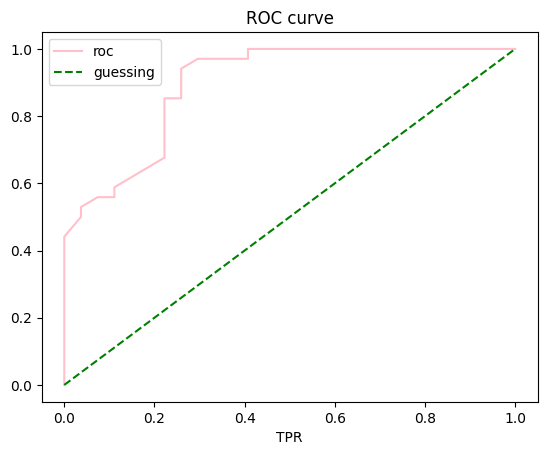

In [20]:
#plot of roc curve
plt.plot(fpr, tpr, color = "pink", label = "roc")
#plot line with no predictive power
plt.plot([0,1],[0,1], linestyle = "--", color = "green", label = "guessing")

plt.ylabel("FPR")
plt.xlabel("TPR")
plt.title("ROC curve")
plt.legend()

#roc curve score
from sklearn.metrics import roc_auc_score

print(f"{roc_auc_score(y_test, y_probs_positive)} is the score of roc curve score")

**confusion matrix** : is quick way to compare the labels a model predicts and the actual labels it was suppose to predict 

simply it says where the model get confused


In [21]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(x_test)

print(confusion_matrix(y_preds, y_test))

pd.crosstab(y_test, y_preds, rownames=["Actual Value"], colnames=["Predicted Values"])

[[20  3]
 [ 7 31]]


Predicted Values,0,1
Actual Value,,
0,20,7
1,3,31


in the above when (0,1) we have 11 cases where our model got confused and (1,0) is 5 is where our model got confused
and (0,0) TNR which is 17 accruate and (1,1) TPR is 28 which is accurate

<Axes: >

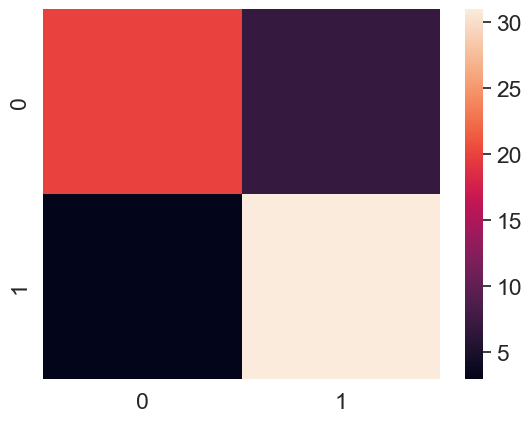

In [22]:
import seaborn as sns 

#set font scale
sns.set(font_scale=1.5)

con_mat = confusion_matrix(y_test, y_preds)

sns.heatmap(con_mat)

learn how to use seaborn heatmap to represent confusion matrix more visually...

In [23]:
clf.score(x_test, y_test)

0.8360655737704918

classification_report is collection of evaluation matrices

1. Precision: Percentage of correct positive predictions relative to total positive predictions.

2. Recall: Percentage of correct positive predictions relative to total actual positives.

3. F1 Score: A weighted harmonic mean of precision and recall. The closer to 1, the better the model.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_preds, y_test))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80        23
           1       0.91      0.82      0.86        38

    accuracy                           0.84        61
   macro avg       0.83      0.84      0.83        61
weighted avg       0.85      0.84      0.84        61



In [25]:
print(confusion_matrix(y_preds, y_test))
print(accuracy_score(y_preds, y_test))

[[20  3]
 [ 7 31]]
0.8360655737704918


In [26]:
#improve the model
#try diffrent amount of n_estimators
np.random.seed(42)
#the above statement ensures that when data is splitted for training and testing always same data goes into training
#and then testing increasing consistency


for i in range(10, 100, 10):
    print(f"Trying model with {i} estimators")
    clf = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"model accuracy on test sets: {clf.score(x_test, y_test)}")
    print("")

Trying model with 10 estimators
model accuracy on test sets: 0.7704918032786885

Trying model with 20 estimators
model accuracy on test sets: 0.7868852459016393

Trying model with 30 estimators
model accuracy on test sets: 0.8032786885245902

Trying model with 40 estimators
model accuracy on test sets: 0.819672131147541

Trying model with 50 estimators
model accuracy on test sets: 0.819672131147541

Trying model with 60 estimators
model accuracy on test sets: 0.8032786885245902

Trying model with 70 estimators
model accuracy on test sets: 0.7868852459016393

Trying model with 80 estimators
model accuracy on test sets: 0.8032786885245902

Trying model with 90 estimators
model accuracy on test sets: 0.8032786885245902



6. <b>Saving and loading trained machine learning models</b>
<p>Two ways to save and load machine learning models:</p>

<ol>
<li>With Python's pickle module
<li>With the joblib module

In [27]:
#save the model and load it

import pickle
pickle.dump(clf, open("random-forest-model-1", "wb"))

In [28]:
#opening the model
load_model = pickle.load(open("random-forest-model-1", "rb"))
load_model.score(x_test, y_test)

0.8032786885245902

In [29]:
#using joblib, joblib will be used when we have model data very large

from joblib import dump, load

dump(clf, filename="random-forest-model.joblib")

['random-forest-model.joblib']

In [42]:
#opening saved file

joblib_loaded = load(filename="random-forest-model.joblib")
joblib_loaded

RandomForestClassifier(n_estimators=90)

In [30]:
#taking care of data file which contains string type of data(transforming the data)

In [31]:
car_sales = pd.read_csv('./datasets/car-sales.csv')

#x and y labeling
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

#split into traning and testing
x_train1, x_test1, y_train1, y_test1 = train_test_split(x,y, test_size=0.2)


In [1]:
#bulding machine learning model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

model.fit(x_train1, y_train1)
model.score(x_test1, y_test1)

##this does not execute because strings cannot be converted into numberical data for 
# calculations so we need to transform the data into numerical

NameError: name 'x_train1' is not defined

In [33]:
#turn the data set which comes under catogery into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)], remainder = "passthrough")
#we are saying to model that to take categorical_features that to be converted
#  and remaining which does not come under category is passed
transformed_x = transformer.fit_transform(x)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [34]:
#this data consists of non numeric
x.head

<bound method NDFrame.head of        Make Colour  Odometer (KM)  Doors
0     Honda  White          35431      4
1       BMW   Blue         192714      5
2     Honda  White          84714      4
3    Toyota  White         154365      4
4    Nissan   Blue         181577      3
..      ...    ...            ...    ...
995  Toyota  Black          35820      4
996  Nissan  White         155144      3
997  Nissan   Blue          66604      4
998   Honda  White         215883      4
999  Toyota   Blue         248360      4

[1000 rows x 4 columns]>

In [35]:
#this data is converted data from non numberic
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [36]:
#we can use another method to transform the data which is dummies

dummies = pd.get_dummies(car_sales[["Make", "Colour", "Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [37]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(transformed_x,y, test_size=0.2)

model.fit(x_train1, y_train1)


RandomForestRegressor()

In [38]:
model.score(x_test1, y_test1)

0.35249118693563875